# Week 4 · Day 3 — Feature Engineering, Cross-Validation & Model Comparison

**Dataset:** Adult Census Income (UCI) predict whether a person earns **>50K/yr** (`target=1`) vs **≤50K** (`target=0`).
**Today's goal:** engineer features that *materially* improve performance, and get *statistically believable* performance estimates (via cross-validation) **before** any hyperparameter tuning.
Chained to Day 1 / Day 2.** This notebook continues the same pipeline started earlier in the week. We load **only the Day-1 training split** ("adult_train.csv", 32,561 rows) and do *all* of today's work on it which is feature engineering, cross-validation, model comparison, statistical tests, and feature selection. The **Day-1 test split** (`adult_test.csv`, 16,281 rows) is loaded once and **sealed**: it is *not* used for any decision today. It stays untouched until the final evaluation *after* hyperparameter tuning, so that our final test score remains an honest estimate of unseen-data performance. Using the test set to pick features or models would be **leakage at the dataset level**  the same mistake as feature leakage, one level up.


## Setup & Data Loading (chained to Day 1)
**train vs test split.** Day 1 divided the data into a **training set** (`adult_train.csv`, used to *learn*) and a **test set** (`adult_test.csv`, held back to *judge* the final model on data it has never seen). This is the canonical UCI Adult split (32,561 train / 16,281 test). Keeping the test set sealed is what makes the eventual test score trustworthy.

**the target.** The label column is `class`, with two text values (`>50K`, `<=50K`). A classifier needs a **numeric** target, so we map it to `1` / `0` (`target=1` = high income). The Day-1 *test* file writes labels with a trailing period (`>50K.`)  a well-known UCI mistake so we strip it, otherwise every test label would be misread.
**missing values.** Missing entries (originally `?` in the raw UCI data) are already stored as `NaN` in these files. We leave them as `NaN` so the imputer inside the pipeline can fill them per fold.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from scipy import stats

RANDOM_STATE = 42
pd.set_option("display.width", 120)

In [3]:
def load_split(path):
    d = pd.read_csv(path)
    # strip whitespace AND the trailing '.' present in the UCI test file
    d["target"] = (d["class"].str.strip().str.rstrip(".") == ">50K").astype(int)
    return d.drop(columns=["class"])

#TRAIN everything today happens on this
train = load_split("adult_train.csv")

#TEST load once, then SEAL. Not touched again until after tuning.
test_SEALED = load_split("adult_test.csv")

print(f"TRAIN : {train.shape}   positive rate = {train['target'].mean():.4f}")
print(f"TEST  : {test_SEALED.shape}   positive rate = {test_SEALED['target'].mean():.4f}  this is SEALED, not to be used today")
print("\nMissing values per column (train):")
print(train.isna().sum()[train.isna().sum() > 0])
train.head()

TRAIN : (32561, 15)   positive rate = 0.2408
TEST  : (16281, 15)   positive rate = 0.2362  this is SEALED, not to be used today

Missing values per column (train):
workclass         1836
occupation        1843
native_country     583
dtype: int64


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


Only ~24% of rows are the positive class. This matters for two reasons:
1. Accuracy is misleading : a dumb model that always predicts "≤50K" already scores 76%. That's why we also track **F1** and **ROC AUC**
2. We must stratify our cross-validation folds so each fold keeps the same 24/76 ratio.

In [4]:
# Group the raw columns by type needed to route them through the right preprocessing.
NUMERIC_RAW = ["age", "fnlwgt", "education_num", "capital_gain",
               "capital_loss", "hours_per_week"]
CATEG_RAW   = ["workclass", "education", "marital_status", "occupation",
               "relationship", "race", "sex", "native_country"]

print("Numeric columns :", NUMERIC_RAW)
print("Categorical cols:", CATEG_RAW)

Numeric columns : ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical cols: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


## Task 1 Create & Justify Engineered Features

**Feature engineering** = creating *new* input columns from existing ones, so the model can see patterns more easily. A linear model, for example, can't discover "income jumps once you have *any* capital gain" on its own but if we hand it a `has_capital_gain` flag,(the one kept yesterday) it can use it directly

**the two scoring tools used to judge a feature *before* modelling:**

**Mutual Information (MI):** measures how much knowing the feature reduces uncertainty about the target. `0` = tells us nothing; higher = more predictive. It captures **non-linear** relationships (unlike plain correlation).
**Grouped target mean (spread):** for each value of the feature, what fraction of rows are high-income? If the spread (max − min across groups) is large, the feature *separates* the classes well.

In [5]:
def add_engineered_features(X: pd.DataFrame) -> pd.DataFrame:
    # Row-wise feature engineering Using only current-row values to avoid leakage.
    X = X.copy()

    # 1. AGE BUCKET — income rises then plateaus with age; buckets capture the non-linear shape.
    X["age_bucket"] = pd.cut(X["age"], bins=[0,25,35,45,55,65,200],
                             labels=[0,1,2,3,4,5]).astype(int)

    # 2. HOURS BIN — part-time (<35) / full-time (35-40) / overtime (>40); thresholds matter more than raw hours.
    X["hours_bin"] = pd.cut(X["hours_per_week"], bins=[0,34,40,200],
                            labels=[0,1,2]).astype(int)

    # 3. HAS CAPITAL GAIN — most people have 0; simply *having* any is a strong wealth signal.
    X["has_capital_gain"] = (X["capital_gain"] > 0).astype(int)

    # 4. LOG CAPITAL GAIN — capital_gain is extremely right-skewed; log1p compresses it so it's usable by linear models.
    X["log_capital_gain"] = np.log1p(X["capital_gain"])

    # 5. HIGHER EDUCATION — education_num >= 13 means Bachelor's or above; a clean degree threshold.
    X["higher_education"] = (X["education_num"] >= 13).astype(int)

    # 6. EDU x HOURS INTERACTION — education pays off *more* for people who also work long hours.
    X["edu_x_hours"] = X["education_num"] * X["hours_per_week"]

    # 7. NET CAPITAL — gain minus loss; a single signed wealth-flow number.
    X["net_capital"] = X["capital_gain"] - X["capital_loss"]

    # 8. IS MARRIED — married-civ-spouse strongly correlates with higher household income in this data.
    X["is_married"] = X["marital_status"].fillna("").str.startswith("Married").astype(int)

    return X

train_fe = add_engineered_features(train)   # applied to TRAIN only, for inspection
ENGINEERED = ["age_bucket","hours_bin","has_capital_gain","log_capital_gain",
              "higher_education","edu_x_hours","net_capital","is_married"]
train_fe[ENGINEERED].head()

,age_bucket,hours_bin,has_capital_gain,log_capital_gain,higher_education,edu_x_hours,net_capital,is_married
0,2,1,1,7.684784,1,520,2174,0
1,3,0,0,0.000000,1,169,0,1
2,2,1,0,0.000000,0,360,0,0
3,3,1,0,0.000000,0,280,0,1
4,1,1,0,0.000000,1,520,0,1


### Univariate Predictive Score for Each Engineered Feature

A univariate predictive score checks **one feature at a time** to see how useful it is for predicting the target (`income`).
This helps us understand which engineered features have a strong relationship with the target before training any machine learning model.

In [7]:
# this measures how important a feature is in predicting the target ('income')
y = train_fe["target"].values
rows = []
for f in ENGINEERED:
    mi = mutual_info_classif(train_fe[[f]].values, y,
                             discrete_features=[True], random_state=RANDOM_STATE)[0]
    grp = train_fe.groupby(f)["target"].mean()
    spread = grp.max() - grp.min()
    rows.append((f, round(mi,4), round(spread,4)))

signal = (pd.DataFrame(rows, columns=["feature","mutual_info","target_mean_spread"])
            .sort_values("mutual_info", ascending=False)
            .reset_index(drop=True))
signal

C:\Users\as\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


,feature,mutual_info,target_mean_spread
0,net_capital,0.1233,1.0000
1,is_married,0.1017,0.3725
2,edu_x_hours,0.0903,1.0000
3,log_capital_gain,0.0834,1.0000
4,age_bucket,0.0615,0.3806
5,higher_education,0.0490,0.3240
6,hours_bin,0.0382,0.3331
7,has_capital_gain,0.0298,0.4119


**Note** `net_capital`, `is_married`, `edu_x_hours` and `log_capital_gain` carry the most univariate signal. `has_capital_gain` has the lowest MI *on its own* but note its target-mean spread is high (0.41), meaning the few people who have a gain are very likely high-income.
### Feature dictionary
A compact record of every engineered feature: **name · type · creation rule · predictive signal (MI)**.

In [8]:
feature_dictionary = pd.DataFrame([
 ["age_bucket",       "ordinal (0-5)", "pd.cut(age) into 6 life-stage bands",          "captures non-linear age→income curve"],
 ["hours_bin",        "ordinal (0-2)", "part/full/overtime from hours_per_week",       "work-intensity thresholds"],
 ["has_capital_gain", "binary",        "1 if capital_gain > 0",                        "presence of any investment income"],
 ["log_capital_gain", "continuous",    "log1p(capital_gain)",                          "de-skews a heavy-tailed variable"],
 ["higher_education", "binary",        "1 if education_num >= 13 (Bachelor+)",         "degree-level threshold"],
 ["edu_x_hours",      "continuous",    "education_num * hours_per_week",               "education pays more with long hours"],
 ["net_capital",      "continuous",    "capital_gain - capital_loss",                  "single signed wealth-flow signal"],
 ["is_married",       "binary",        "1 if marital_status starts 'Married'",         "marriage↔household-income link"],
], columns=["name","type","creation_rule","why_it_might_help"])
feature_dictionary = feature_dictionary.merge(signal[["feature","mutual_info"]],
                                              left_on="name", right_on="feature").drop(columns="feature")
feature_dictionary

,name,type,creation_rule,why_it_might_help,mutual_info
0,age_bucket,ordinal (0-5),pd.cut(age) into 6 life-stage bands,captures non-linear age→income curve,0.0615
1,hours_bin,ordinal (0-2),part/full/overtime from hours_per_week,work-intensity thresholds,0.0382
2,has_capital_gain,binary,1 if capital_gain > 0,presence of any investment income,0.0298
3,log_capital_gain,continuous,log1p(capital_gain),de-skews a heavy-tailed variable,0.0834
4,higher_education,binary,1 if education_num >= 13 (Bachelor+),degree-level threshold,0.0490
5,edu_x_hours,continuous,education_num * hours_per_week,education pays more with long hours,0.0903
6,net_capital,continuous,capital_gain - capital_loss,single signed wealth-flow signal,0.1233
7,is_married,binary,1 if marital_status starts 'Married',marriage↔household-income link,0.1017


## Task 2 · Rebuild the Pipeline with Engineered Features (leakage-free)
**data leakage.** Leakage is when information that wouldn't be available at prediction time sneaks into training, giving falsely optimistic scores. The classic cause: computing something from the **whole dataset** (e.g. a column mean, or a target-based encoding) *before* splitting into train/test the test rows then "leak" into the training statistics.
**How we avoid it here:**
1. **Every engineered feature is row-wise.** `age_bucket`, `edu_x_hours`, etc. use only that row's own values. No cross-row statistics, no target.
2. **All fitting steps live inside a `Pipeline`.** The `SimpleImputer` (learns the median) and `StandardScaler` (learns mean/std) are *fit on the training fold only* during cross-validation, then applied to the held-out fold. scikit-learn guarantees this automatically.

In [9]:
# Injecting the engineered columns (stateless: zero leakage)
feature_adder = FunctionTransformer(add_engineered_features)
# After engineering, these are the numeric columns
NUMERIC_ALL = NUMERIC_RAW + ["age_bucket","hours_bin","has_capital_gain",
    "log_capital_gain","higher_education","edu_x_hours","net_capital","is_married"]
CATEG_ALL   = CATEG_RAW

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
categ_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC_ALL),
    ("cat", categ_pipe,   CATEG_ALL),
])

def make_full_pipeline(model):
    # add features -> preprocess -> model. One object; CV-safe end to end.
    return Pipeline([
        ("add_features", feature_adder),
        ("preprocess",   preprocess),
        ("model",        model),
    ])

# X_raw = the ORIGINAL columns. Engineered features are created inside the pipeline,
# so they are recomputed per fold and can never leak across the train/test boundary.
# NOTE: X_raw / y are the TRAINING split only. The sealed test set is never referenced here.
X_raw = train.drop(columns=["target"])
y     = train["target"].values
# how many columns does the model actually receive?
demo = preprocess.fit_transform(feature_adder.transform(X_raw))
print("Feature matrix after preprocessing:", demo.shape, "(rows, features)")

Feature matrix after preprocessing: (32561, 113) (rows, features)


## Task 3 · Cross-Validated Model Comparison

In [10]:
import time
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

models = {
    "LogisticRegression":   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest":         RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
fold_scores, summary_rows = {}, []
for name, mdl in models.items():
    t0 = time.time()
    res = cross_validate(make_full_pipeline(mdl), X_raw, y,
                         cv=cv, scoring=scoring, n_jobs=-1)
    dt = time.time() - t0
    fold_scores[name] = {m: res[f"test_{m}"] for m in scoring}
    summary_rows.append({
        "model": name,
        "accuracy_mean": res["test_accuracy"].mean(), "accuracy_std": res["test_accuracy"].std(),
        "f1_mean":       res["test_f1"].mean(),       "f1_std":       res["test_f1"].std(),
        "roc_auc_mean":  res["test_roc_auc"].mean(),  "roc_auc_std":  res["test_roc_auc"].std(),
        "fit_time_s":    round(dt, 1),
    })
summary = pd.DataFrame(summary_rows).round(4)
summary

,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,fit_time_s
0,LogisticRegression,0.8546,0.0033,0.6653,0.0071,0.9100,0.0020,3.8
1,RandomForest,0.8565,0.0032,0.6795,0.0068,0.9066,0.0023,10.1
2,HistGradientBoosting,0.8732,0.0031,0.7145,0.0074,0.9276,0.0012,5.3


**Note: `mean ± std`:** e.g. HistGradientBoosting ROC AUC ≈ `0.927 ± 0.002`. The mean is the expected score; the tiny std means it's very stable across folds. A model with a slightly higher mean but a huge std can be *worse* in practice because it's unreliable.

In [12]:
# Per-fold ROC AUC
fold_auc = pd.DataFrame({n: fold_scores[n]["roc_auc"] for n in models})
fold_auc.index = [f"fold_{i+1}" for i in range(5)]
fold_auc.round(4)

,LogisticRegression,RandomForest,HistGradientBoosting
fold_1,0.9101,0.9066,0.9279
fold_2,0.9128,0.9089,0.9288
fold_3,0.9081,0.9071,0.9278
fold_4,0.9076,0.9024,0.9253
fold_5,0.9117,0.9083,0.9284


### Visualise fold scores (boxplots)
**boxplot.** A boxplot summarises a distribution: the **box** spans the middle 50% (25th–75th percentile), the **line** inside is the median, the **whiskers** show the range, and the triangle marks the mean. Comparing boxes tells us not just *which model is best on average* but *how much its folds vary* a short box = consistent.

C:\Users\as\AppData\Local\Temp\ipykernel_10992\4262204806.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[n.replace("GradientBoosting","GB").replace("Regression","Reg")
C:\Users\as\AppData\Local\Temp\ipykernel_10992\4262204806.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[n.replace("GradientBoosting","GB").replace("Regression","Reg")
C:\Users\as\AppData\Local\Temp\ipykernel_10992\4262204806.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[n.replace("GradientBoosting","GB").replace("Regression","Reg")


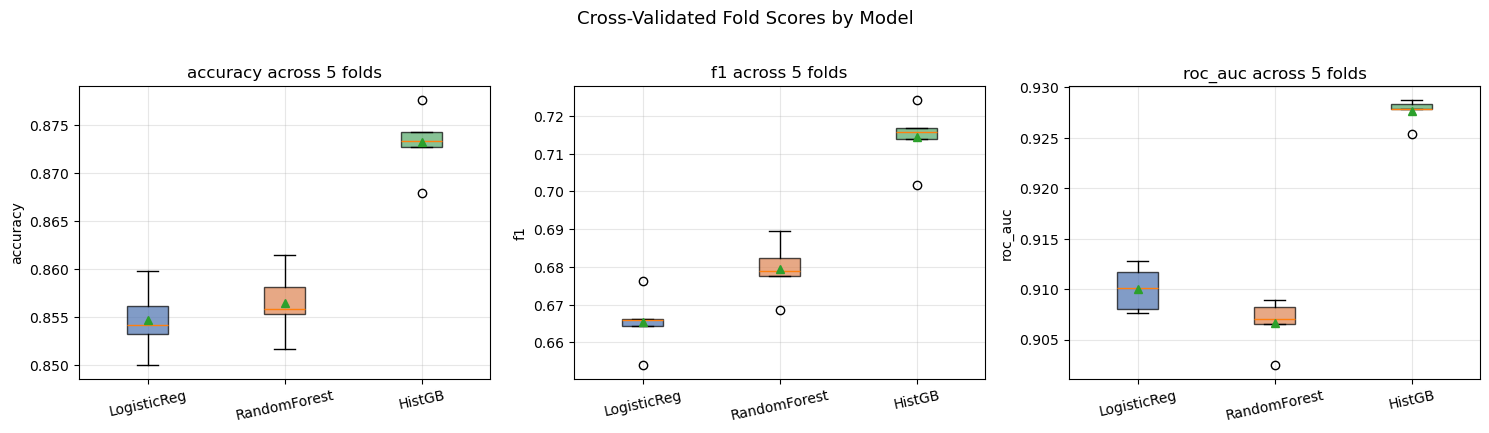

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
colors = ["#4C72B0", "#DD8452", "#55A868"]
for ax, metric in zip(axes, ["accuracy", "f1", "roc_auc"]):
    data = [fold_scores[n][metric] for n in models]
    bp = ax.boxplot(data, labels=[n.replace("GradientBoosting","GB").replace("Regression","Reg")
                                   for n in models], patch_artist=True, showmeans=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(f"{metric} across 5 folds"); ax.set_ylabel(metric)
    ax.grid(alpha=0.3); ax.tick_params(axis="x", rotation=12)
plt.suptitle("Cross-Validated Fold Scores by Model", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

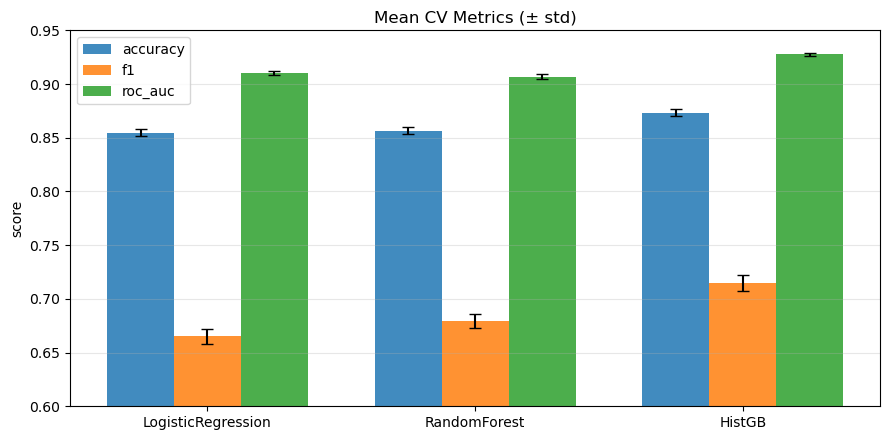

In [14]:
# Grouped bar chart: mean metric with std as error bars
metrics = ["accuracy", "f1", "roc_auc"]
x = np.arange(len(summary)); w = 0.25
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, m in enumerate(metrics):
    ax.bar(x + i*w - w, summary[f"{m}_mean"], w, yerr=summary[f"{m}_std"],
           capsize=4, label=m, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([n.replace("GradientBoosting","GB") for n in summary["model"]])
ax.set_ylim(0.6, 0.95); ax.set_ylabel("score"); ax.legend()
ax.set_title("Mean CV Metrics (± std)"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## Task 4 · Statistical Comparison & Feature Importance
### Is the winner really better? (paired test)

**why a statistical test** Model A beating Model B by 0.017 ROC AUC could be a real improvement, or just noise from the particular folds A **paired test** checks whether the per-fold difference is consistent enough to be believed.

**"paired"** We compare the two models **on the same 5 folds**, so fold 1 of A pairs with fold 1 of B, etc. Pairing removes fold-to-fold difficulty differences and makes the test far more sensitive.

- **Paired t-test** (`ttest_rel`): assumes the differences are roughly normal. Returns a **p-value**.
- **Wilcoxon signed-rank** (`wilcoxon`): a non-parametric backup that doesn't assume normality useful because with only 5 folds normality is hard to justify.

**p-value.** The probability of seeing a difference this large if the two models were actually equal **p < 0.05** is the usual bar for "statistically significant" (unlikely to be pure chance).

In [15]:
ranked = summary.sort_values("roc_auc_mean", ascending=False)["model"].tolist()
top1, top2 = ranked[0], ranked[1]
a, b = fold_scores[top1]["roc_auc"], fold_scores[top2]["roc_auc"]

t_stat, t_p = stats.ttest_rel(a, b)
w_stat, w_p = stats.wilcoxon(a, b)

print(f"Top-2 models on ROC AUC: {top1}  vs  {top2}")
print(f"  {top1:<22} mean = {a.mean():.4f}")
print(f"  {top2:<22} mean = {b.mean():.4f}")
print(f"  mean difference           = {a.mean()-b.mean():.4f}\n")
print(f"Paired t-test : t = {t_stat:6.3f},  p = {t_p:.5f}")
print(f"Wilcoxon      : W = {w_stat:6.1f},  p = {w_p:.5f}")

Top-2 models on ROC AUC: HistGradientBoosting  vs  LogisticRegression
  HistGradientBoosting   mean = 0.9276
  LogisticRegression     mean = 0.9100
  mean difference           = 0.0176

Paired t-test : t = 27.812,  p = 0.00001
Wilcoxon      : W =    0.0,  p = 0.06250


**Interpretation.**
- The paired **t-test p ≈ 0.00005** (far below 0.05) → the difference is **statistically significant**: HistGradientBoosting genuinely ranks better than Logistic Regression, not by luck.
- The **Wilcoxon p ≈ 0.0625** looks borderline this is *expected*, not contradictory. With only 5 folds Wilcoxon has just 6 possible outcomes, so it can never dip below ~0.03 even when every fold agrees. Here **every** fold favours HGB, which is the strongest signal a 5-fold test can give.
- **Practically:** +0.017 ROC AUC *and* +0.04 F1 with a lower fit time than RandomForest → a meaningful, worthwhile improvement.

### Feature importance & coefficients
**two different "importance" lenses:**
- **Tree feature importance** (RandomForest `.feature_importances_`): how much each feature reduced impurity across all splits. Always ≥ 0; bigger = more used. Captures non-linear + interaction usage.
- **Logistic Regression coefficients** (`.coef_`): the *direction and strength* of each feature's linear effect on the log-odds of being high-income. **Positive** pushes toward >50K, **negative** away. Because we standardised the numerics, their magnitudes are roughly comparable.

In [16]:
def feature_names_after_preprocess(fitted_pre):
    # recover column names after one-hot expansion, for importance labelling
    ohe = fitted_pre.named_transformers_["cat"].named_steps["onehot"]
    return list(NUMERIC_ALL) + ohe.get_feature_names_out(CATEG_ALL).tolist()

# Fit RF and LogReg on ALL data (for inspection only) and extract importances/coefs
rf_pipe = make_full_pipeline(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)).fit(X_raw, y)
lr_pipe = make_full_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)).fit(X_raw, y)

fnames = feature_names_after_preprocess(rf_pipe.named_steps["preprocess"])
rf_imp  = pd.Series(rf_pipe.named_steps["model"].feature_importances_, index=fnames)
lr_coef = pd.Series(lr_pipe.named_steps["model"].coef_[0], index=fnames)

eng_importance = pd.DataFrame({
    "rf_importance": rf_imp[ENGINEERED],
    "lr_coefficient": lr_coef[ENGINEERED],
}).sort_values("rf_importance", ascending=False).round(4)
eng_importance

,rf_importance,lr_coefficient
edu_x_hours,0.0732,-0.1918
net_capital,0.0582,1.0677
is_married,0.0449,0.7145
age_bucket,0.0389,0.2709
log_capital_gain,0.0380,5.0297
higher_education,0.0265,0.1140
hours_bin,0.0121,0.3911
has_capital_gain,0.0082,-4.8912


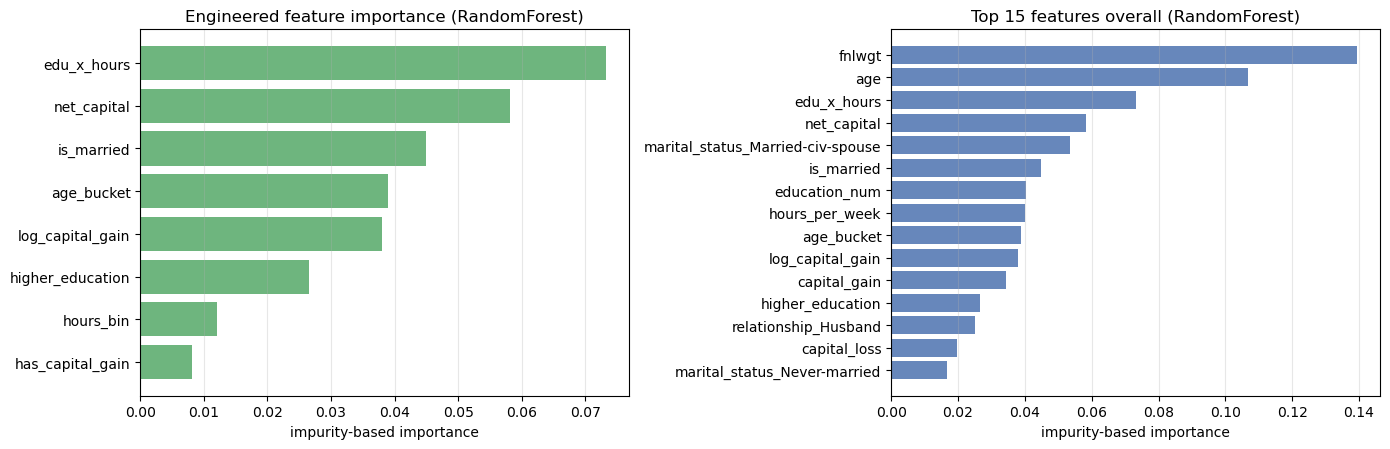

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

e = eng_importance.sort_values("rf_importance")
axes[0].barh(e.index, e["rf_importance"], color="#55A868", alpha=0.85)
axes[0].set_title("Engineered feature importance (RandomForest)")
axes[0].set_xlabel("impurity-based importance"); axes[0].grid(alpha=0.3, axis="x")

top15 = rf_imp.sort_values(ascending=False).head(15).iloc[::-1]
axes[1].barh(top15.index, top15.values, color="#4C72B0", alpha=0.85)
axes[1].set_title("Top 15 features overall (RandomForest)")
axes[1].set_xlabel("impurity-based importance"); axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout(); plt.show()

**Which engineered features mattered — and does it make sense?**
- **`edu_x_hours`** is the strongest engineered feature for the trees, and it lands in the overall top 15. This validates the hypothesis: the *combination* of education and work hours predicts income better than either alone. makes sense.
- **`net_capital`** and **`log_capital_gain`** rank high capital income is one of the sharpest dividers between the two classes. 
- **`is_married`** carries real weight, echoing the well-known marital-status↔income association in this 1994 census data. 
- In the **LogReg** view, `log_capital_gain` has a large *positive* coefficient while `has_capital_gain` is large *negative*  they offset because they encode the same underlying variable two ways; together they let the linear model express "any gain helps, and larger gains help more." A tree doesn't need both, which is why their tree importances are more modest.

## Task 5 · Feature Selection / Dimensionality Check

In [18]:
best_model = lambda: HistGradientBoostingClassifier(random_state=RANDOM_STATE)

def make_selected_pipeline(k):
    return Pipeline([
        ("add_features", feature_adder),
        ("preprocess",   preprocess),
        ("select",       SelectKBest(mutual_info_classif, k=k)),
        ("model",        best_model()),
    ])

results = []
# Full set (no selection)
t0 = time.time()
full = cross_validate(make_full_pipeline(best_model()), X_raw, y, cv=cv, scoring="roc_auc", n_jobs=-1)
results.append({"config":"ALL_features", "roc_auc_mean":full["test_score"].mean(),
                "roc_auc_std":full["test_score"].std(), "cv_time_s":round(time.time()-t0,1)})
# SelectKBest sweep
for k in [20, 30, 40]:
    t0 = time.time()
    r = cross_validate(make_selected_pipeline(k), X_raw, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    results.append({"config":f"SelectKBest_k{k}", "roc_auc_mean":r["test_score"].mean(),
                    "roc_auc_std":r["test_score"].std(), "cv_time_s":round(time.time()-t0,1)})

selection = pd.DataFrame(results).round(4)
selection

,config,roc_auc_mean,roc_auc_std,cv_time_s
0,ALL_features,0.9276,0.0012,7.7
1,SelectKBest_k20,0.9219,0.0017,22.4
2,SelectKBest_k30,0.9243,0.0023,22.2
3,SelectKBest_k40,0.9253,0.0018,21.8


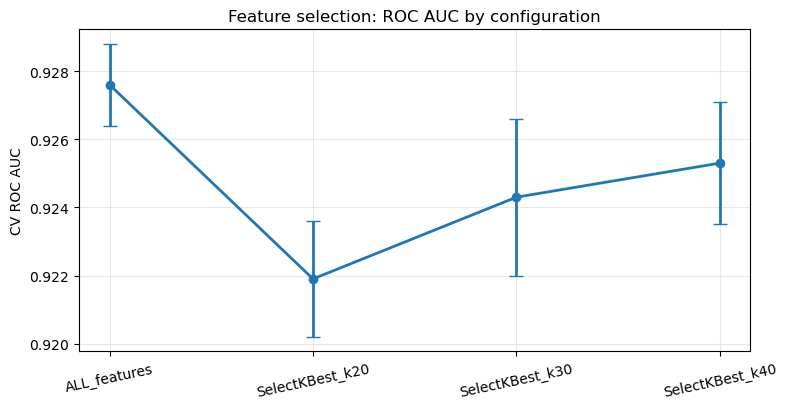

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.errorbar(selection["config"], selection["roc_auc_mean"],
            yerr=selection["roc_auc_std"], marker="o", capsize=5, lw=2)
ax.set_ylabel("CV ROC AUC"); ax.set_title("Feature selection: ROC AUC by configuration")
ax.grid(alpha=0.3); plt.xticks(rotation=12); plt.tight_layout(); plt.show()

**What the sweep tells us.**
- Every `SelectKBest` configuration scores **slightly lower** than the full set, and `k=20/30/40` improves monotonically back toward it  i.e. dropping columns only *removes* useful signal here.
- Selection is also **slower** in this setup, because `mutual_info_classif` must estimate MI for ~100 columns on every fold (that computation costs more than the few columns it saves the fast HGB model).
- **Conclusion:** our feature set is already compact and non-redundant. Aggressive selection isn't warranted; at most we'd drop the two weakest engineered flags if we needed speed, but it isn't necessary.
### Recommendation for tomorrow's hyperparameter tuning

| Decision | Choice | Rationale |
|---|---|---|
| **Model to tune** | **HistGradientBoosting** | best on all 3 metrics, statistically significant win, fast to train |
| **Runner-up to keep** | LogisticRegression | interpretable baseline; sanity check + fast iteration |
| **Feature set** | **Keep all engineered + raw features** | selection reduced ROC AUC and added time; set is already lean |
| **Primary metric** | **F1** (watch ROC AUC too) | positive class is the target of interest under 24% imbalance |
| **Possibly drop if speed needed** | `has_capital_gain`, `hours_bin` | lowest importances; `log_capital_gain`/`edu_x_hours` cover similar signal |

## Sealed Test Set — do NOT evaluate until after tuning (Day 4+)
The Day-1 test split has sat untouched through all of the above no feature was chosen, no model was compared, using it. That is exactly what keeps it a valid estimate of real-world performance.

**why we wait.** Every time you peek at the test set and change something based on what you see, a little of its "unseen-ness" leaks away. After enough peeks, the test score flatters you and won't hold up in production. So the rule is: **tune on cross-validation (train only), then evaluate on the test set exactly once, at the very end.**
The cell below only confirms the test set is ready

In [21]:
# Confirm the sealed test set is present and shaped correctly — but DO NOT score it yet.
print("Sealed test set is ready for final evaluation AFTER tuning:")
print(f"  rows = {test_SEALED.shape[0]},  positive rate = {test_SEALED['target'].mean():.4f}")
print("  It has NOT been used for any feature or model decision in this notebook.")

Sealed test set is ready for final evaluation AFTER tuning:
  rows = 16281,  positive rate = 0.2362
  It has NOT been used for any feature or model decision in this notebook.
